In [16]:
# cell 1: import libs & raw data
import pandas as pd
from datasets import load_dataset
import os

# 1. loading datasets directly from Hugging Face
print("Loading GoEmotions dataset...")
dataset = load_dataset("go_emotions", "simplified")

# Hugging Face automaticly separate emotions on: train, validation и test. 
# transform them to pandas tables (DataFrames)
df_train = dataset['train'].to_pandas()
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

# 2. save raw data in data/raw/ for backup
os.makedirs('data/raw', exist_ok=True)
df_train.to_csv('data/raw/goemotions_train.csv', index=False)
df_val.to_csv('data/raw/goemotions_val.csv', index=False)
df_test.to_csv('data/raw/goemotions_test.csv', index=False)

print(f"the size of the training sample: {df_train.shape}")
print("the data has been successfully saved in  data/raw/")

# looking at the first 3 lines
df_train.head(3)

Loading GoEmotions dataset...
the size of the training sample: (43410, 3)
the data has been successfully saved in  data/raw/


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj


In [17]:
# cell 2: mapping 27 to 9 targeted classes
import pandas as pd
import numpy as np

# dict of our targeted classes and their corresponding IDs from GoEmotions
TARGET_CLASSES = {
    'sadness': [16, 25],          # 16: grief, 25: sadness
    'anger': [2, 3],              # 2: anger, 3: annoyance
    'fear': [14, 19],             # 14: fear, 19: nervousness
    'disgust': [11],              # 11: disgust
    'anticipation': [8, 20],      # 8: desire, 20: optimism
    'joy': [1, 13, 17, 23],       # 1: amusement, 13: excitement, 17: joy, 23: relief
    'surprise': [22, 26],         # 22: realization, 26: surprise
    'gratitude': [15],            # 15: gratitude
    'love': [18]                  # 18: love
}

def map_emotions(labels_list):
    """maps a list of IDs to a dictionary with our 9 targeted classes (1 - present, 0 - absent)"""
    new_labels = {target: 0 for target in TARGET_CLASSES.keys()}
    for label_id in labels_list:
        for target_name, original_ids in TARGET_CLASSES.items():
            if label_id in original_ids:
                new_labels[target_name] = 1
    return pd.Series(new_labels)

print("executing mapping of classes for the training dataset...")
mapped_labels = df_train['labels'].apply(map_emotions)
df_train_mapped = pd.concat([df_train[['id', 'text']], mapped_labels], axis=1)

df_train_mapped['emotion_count'] = df_train_mapped[TARGET_CLASSES.keys()].sum(axis=1)
df_train_model_b = df_train_mapped[df_train_mapped['emotion_count'] > 0].drop(columns=['emotion_count'])

print(f"size of the dataset for Model B (after filtering): {df_train_model_b.shape}")

executing mapping of classes for the training dataset...
size of the dataset for Model B (after filtering): (18793, 11)


In [18]:
# cell 2.5: saving the processed dataframe
import os

# create directory if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

# save the dataframe to a csv file without the index column
df_train_model_b.to_csv('data/processed/model_b_train_uncleaned.csv', index=False)

print("processed data successfully saved to data/processed/model_b_train_uncleaned.csv")

processed data successfully saved to data/processed/model_b_train_uncleaned.csv


/tmp/ipykernel_1158/2081098581.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.values, y=emotion_counts.index, palette="viridis")


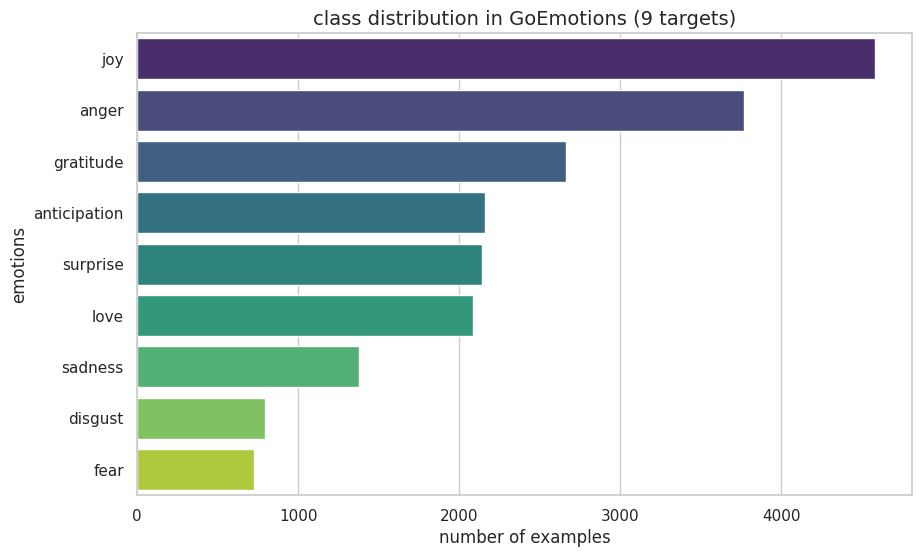

In [19]:
# cell 3: visualizing class distribution for Model B
import matplotlib.pyplot as plt
import seaborn as sns

# calculate the total number of examples for each emotion
target_emotions = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
emotion_counts = df_train_model_b[target_emotions].sum().sort_values(ascending=False)

# set seaborn style and create a horizontal bar plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.values, y=emotion_counts.index, palette="viridis")

# add labels and title
plt.title('class distribution in GoEmotions (9 targets)', fontsize=14)
plt.xlabel('number of examples', fontsize=12)
plt.ylabel('emotions', fontsize=12)

# display the plot
plt.show()

text length statistics:
count    18793.000000
mean        12.979407
std          6.675804
min          1.000000
50%         13.000000
75%         18.000000
90%         23.000000
95%         24.000000
99%         27.000000
max         33.000000
Name: text, dtype: float64


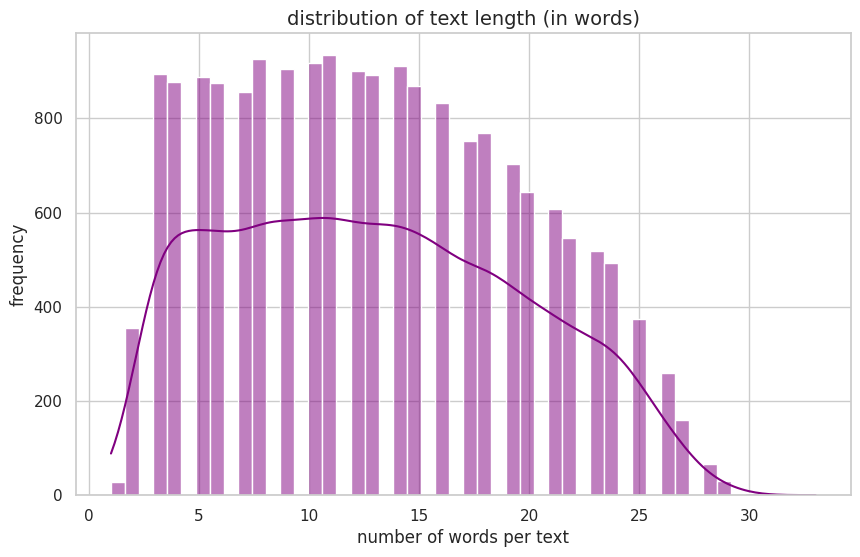

In [20]:
# cell 4: analyzing text length distribution
import matplotlib.pyplot as plt
import seaborn as sns

# calculate length of each text in words
word_count = df_train_model_b['text'].apply(lambda x: len(str(x).split()))

# set style and create a figure
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# plot histogram of word counts
sns.histplot(word_count, bins=50, kde=True, color='purple')

# add labels and title
plt.title('distribution of text length (in words)', fontsize=14)
plt.xlabel('number of words per text', fontsize=12)
plt.ylabel('frequency', fontsize=12)

# print statistics to make decisions
print("text length statistics:")
print(word_count.describe(percentiles=[0.75, 0.90, 0.95, 0.99]))

plt.show()

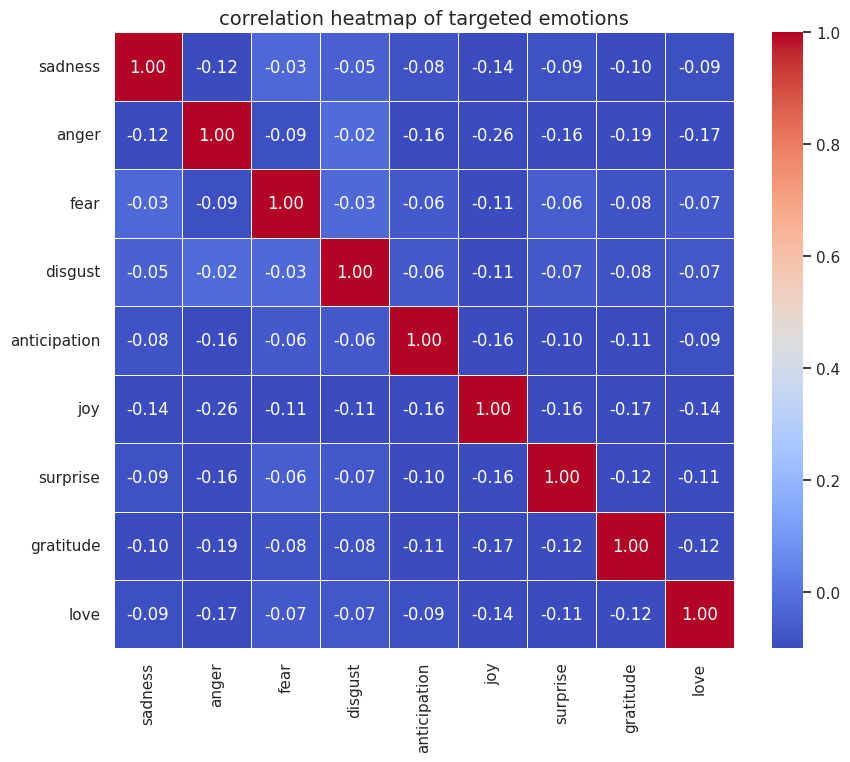

In [21]:
# cell 5: correlation heatmap of emotions
import matplotlib.pyplot as plt
import seaborn as sns

# select only the emotion columns
target_emotions = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
emotions_df = df_train_model_b[target_emotions]

# calculate correlation matrix
corr_matrix = emotions_df.corr()

# plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-0.1, vmax=1.0)

# add title
plt.title('correlation heatmap of targeted emotions', fontsize=14)

plt.show()

generating wordcloud for 'joy'...


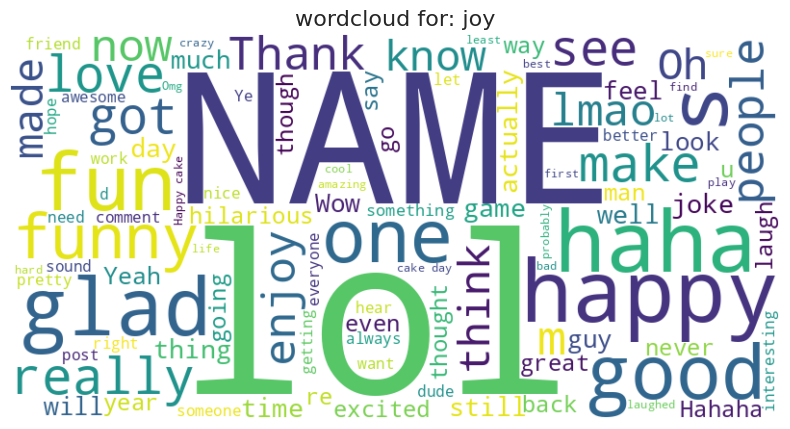

generating wordcloud for 'anger'...


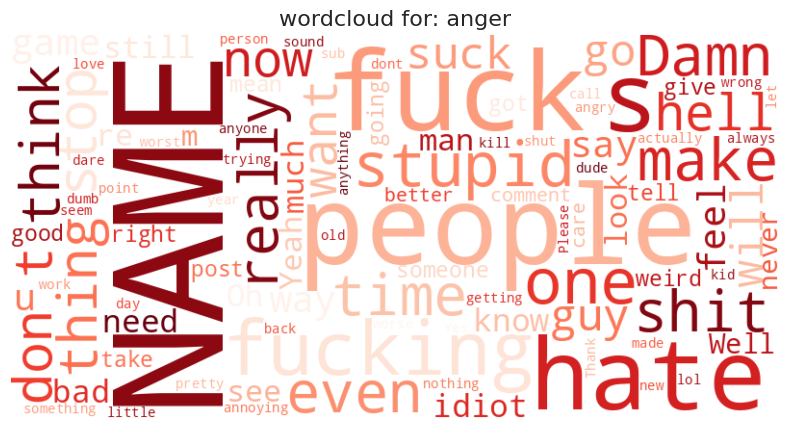

In [13]:
# cell 6: frequency analysis and wordcloud generation
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# function to generate and plot a wordcloud for a specific emotion
def plot_wordcloud(emotion_name, color_map):
    # filter texts that belong to the specified emotion
    texts = df_train_model_b[df_train_model_b[emotion_name] == 1]['text'].values
    
    # combine all texts into one giant string
    combined_text = ' '.join(str(text) for text in texts)
    
    # generate the wordcloud
    # max_words limits the cloud to the top 100 most frequent words
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=color_map, 
                          max_words=100).generate(combined_text)
    
    # plot the image
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'wordcloud for: {emotion_name}', fontsize=16)
    plt.axis('off')
    plt.show()

# generate and display wordclouds for two contrasting emotions
print("generating wordcloud for 'joy'...")
plot_wordcloud('joy', 'viridis')

print("generating wordcloud for 'anger'...")
plot_wordcloud('anger', 'Reds')

In [14]:
# cell 7: downloading sst-2 and saving raw splits
from datasets import load_dataset
import pandas as pd
import os

print("downloading sst-2 dataset...")
# load sst-2 from glue benchmark
sst2_dataset = load_dataset("glue", "sst2")

# convert splits to pandas dataframes
df_sst2_train = sst2_dataset['train'].to_pandas()
df_sst2_val = sst2_dataset['validation'].to_pandas()
df_sst2_test = sst2_dataset['test'].to_pandas()

# ensure directory exists
os.makedirs('data/raw', exist_ok=True)

# save raw data
df_sst2_train.to_csv('data/raw/sst2_train.csv', index=False)
df_sst2_val.to_csv('data/raw/sst2_val.csv', index=False)
df_sst2_test.to_csv('data/raw/sst2_test.csv', index=False)

print(f"saved raw sst-2 train: {df_sst2_train.shape}")
print(f"saved raw sst-2 val: {df_sst2_val.shape}")
print(f"saved raw sst-2 test: {df_sst2_test.shape}")

downloading sst-2 dataset...


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

saved raw sst-2 train: (67349, 3)
saved raw sst-2 val: (872, 3)
saved raw sst-2 test: (1821, 3)


Note: After inspecting the raw SST-2 data, I noticed that the texts are heavily fragmented (parsed into small, contextless phrases like "of saucy" or "cold movie"). This could harm the model's ability to learn real sentence semantics. Decided to switch to the IMDB dataset for Model A.

In [16]:
# cell 8: downloading imdb dataset as an alternative for model a
from datasets import load_dataset
import pandas as pd
import os

print("downloading imdb dataset...")
# load imdb
imdb_dataset = load_dataset("imdb")

# convert to pandas dataframes
df_imdb_train = imdb_dataset['train'].to_pandas()
df_imdb_test = imdb_dataset['test'].to_pandas()

# ensure directory exists
os.makedirs('data/raw', exist_ok=True)

# save raw data
df_imdb_train.to_csv('data/raw/imdb_train.csv', index=False)
df_imdb_test.to_csv('data/raw/imdb_test.csv', index=False)

print(f"saved raw imdb train: {df_imdb_train.shape}")
print(f"saved raw imdb test: {df_imdb_test.shape}")

# display a few examples to verify data quality
df_imdb_train.head(5)

downloading imdb dataset...
saved raw imdb train: (25000, 2)
saved raw imdb test: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [17]:
# cell 9: mapping and combining imdb with neutral goemotions
import pandas as pd
import os

# extract neutral texts from goemotions (label 27)
neutral_mask = df_train['labels'].apply(lambda x: 27 in x)
df_neutral = df_train[neutral_mask][['text']].copy()

# assign label 2 for neutral class
df_neutral['label'] = 2

# combine imdb train and neutral goemotions
df_model_a = pd.concat([df_imdb_train, df_neutral], ignore_index=True)

# shuffle the dataset to mix 0, 1, and 2 labels completely
df_model_a = df_model_a.sample(frac=1, random_state=42).reset_index(drop=True)

# save to processed data
os.makedirs('data/processed', exist_ok=True)
df_model_a.to_csv('data/processed/model_a_train_uncleaned.csv', index=False)

print(f"combined dataset size: {df_model_a.shape}")
print("class counts:")
print(df_model_a['label'].value_counts())

# display a random sample (now you will see different labels)
df_model_a.head(5)

combined dataset size: (39219, 2)
class counts:
label
2    14219
0    12500
1    12500
Name: count, dtype: int64


,text,label
0,I understand there was some conflict between L...,0
1,>he was riding a bike with my other GUY friend...,2
2,The word ‘rap’ was created by a guy who couldn...,2
3,My mom is attractive. My dad is ugly. I look l...,2
4,Everyone wants bama! I repeat everyone wants b...,2


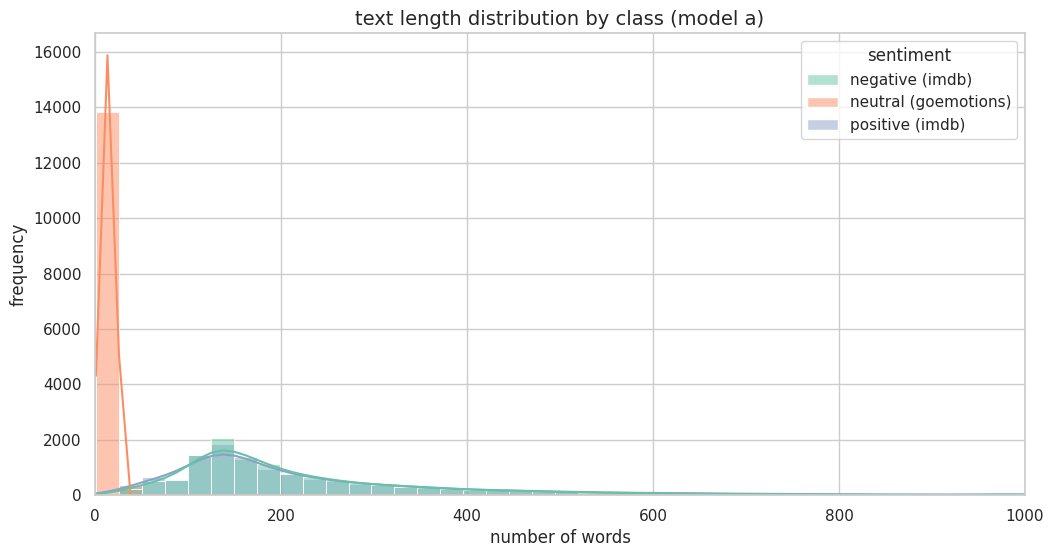

text length statistics by class:
                        count        mean         std   min    50%    75%  \
sentiment                                                                   
negative (imdb)       12500.0  230.867840  166.663126  10.0  174.0  278.0   
neutral (goemotions)  14219.0   12.504185    6.814992   1.0   12.0   18.0   
positive (imdb)       12500.0  236.706560  180.485743  12.0  174.0  291.0   

                        90%     95%     99%     max  
sentiment                                            
negative (imdb)       441.0  575.00  892.03  1522.0  
neutral (goemotions)   22.0   24.00   27.00    32.0  
positive (imdb)       472.0  619.05  924.00  2470.0  


In [18]:
# cell 10: text length distribution for model a
import matplotlib.pyplot as plt
import seaborn as sns

# calculate word count for each text
df_model_a['word_count'] = df_model_a['text'].apply(lambda x: len(str(x).split()))

# map labels for the plot
label_map = {0: 'negative (imdb)', 1: 'positive (imdb)', 2: 'neutral (goemotions)'}
df_model_a['sentiment'] = df_model_a['label'].map(label_map)

# set style and plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# plot histogram with different colors for each class
sns.histplot(data=df_model_a, x='word_count', hue='sentiment', bins=100, kde=True, palette='Set2')

plt.title('text length distribution by class (model a)', fontsize=14)
plt.xlabel('number of words', fontsize=12)
plt.ylabel('frequency', fontsize=12)

# limit x-axis to 1000 to avoid long tails shrinking the main plot
plt.xlim(0, 1000)

plt.show()

# print statistics to see the exact difference
print("text length statistics by class:")
print(df_model_a.groupby('sentiment')['word_count'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]))

### eda conclusions for model a: length imbalance

**observation:**
there is a massive discrepancy in text length between our two data sources. the imdb reviews (positive/negative) have an average length of ~236 words, with many exceeding 500 words. in contrast, the neutral texts extracted from goemotions have an average length of only ~12 words.

**the risk:**
if fed to the model as-is, the algorithm will likely suffer from "length bias". instead of learning the semantic meaning of positive or negative words, it might learn a simple shortcut: "if the text is very long, it is positive/negative; if it is very short, it is neutral."

**solution strategy for the next stages:**
1. **deep cleaning:** apply rigorous preprocessing (removing html tags, stop-words, and punctuation) to condense the long imdb reviews down to their core semantic meaning.
2. **vector normalization:** when building baseline models (stage 4) with tf-idf, use l2-normalization so that the overall mathematical "weight" of a long review equals that of a short comment.
3. **post-cleanup truncation:** for deep learning models (stage 5), apply padding and truncation only *after* the text has been completely cleaned of stop-words, preserving maximum informational density.

### why further eda is skipped for model a

**1. correlation matrix is irrelevant:**
unlike our emotion model (which is multi-label), model a is a strict multi-class classification task. a single text cannot physically be simultaneously "positive" and "neutral". therefore, a correlation heatmap would only show obvious negative correlations (mutual exclusivity) between all classes, providing no new insights.

**2. wordclouds are postponed to stage 2:**
generating wordclouds on the raw imdb dataset right now would only visualize noise (html tags like `<br />`, stop-words like `the`, `and`, and generic terms like `movie`, `film`). to see the true semantic markers of positive or negative sentiment, we must first run our text cleaning pipeline (stage 2) and build the wordclouds on the lemmatized, purified data.

### data dictionary: label mappings across models

to prevent confusion, here is the official mapping of numeric labels to their text meanings for all models in this project:

**model a (sentiment analysis)**
* `0` = negative (source: imdb)
* `1` = positive (source: imdb)
* `2` = neutral (source: goemotions, original label 27)

**model b (emotion classification - multi-label)**
* binary `0` (absent) or `1` (present) for 9 classes:
  `sadness`, `anger`, `fear`, `disgust`, `anticipation`, `joy`, `surprise`, `gratitude`, `love`

**model c (style classification)**
* `0` = informal / colloquial / slang
* `1` = formal / polite / business

In [12]:
# cell 11: downloading and preparing dataset for formality classification
from datasets import load_dataset
import pandas as pd
import os

print("downloading pavlick formality scores dataset...")
# load the dataset
dataset = load_dataset("osyvokon/pavlick-formality-scores")

# convert to pandas
df_raw = dataset['train'].to_pandas()

# ensure directory exists
os.makedirs('data/raw', exist_ok=True)

# save raw data
df_raw.to_csv('data/raw/pavlick-formality-scores_train.csv', index=False)

print(f"saved raw pavlick-formality-scores_train raw dataset: {df_raw.shape}")

# rename sentence to text to match our standard
df_raw = df_raw.rename(columns={'sentence': 'text'})

# filter out neutral sentences to create a clear boundary
# formal: score > 0.5, informal: score < -0.5
df_formal = df_raw[df_raw['avg_score'] > 0.5].copy()
df_formal['label'] = 1

df_informal = df_raw[df_raw['avg_score'] < -0.5].copy()
df_informal['label'] = 0

# combine into a single dataset for binary classification
df_formality = pd.concat([df_informal, df_formal], ignore_index=True)[['text', 'label']]

# shuffle the data completely
df_formality = df_formality.sample(frac=1, random_state=42).reset_index(drop=True)

# save the uncleaned dataset
os.makedirs('data/processed', exist_ok=True)
df_formality.to_csv('data/processed/model_c_train_uncleaned.csv', index=False)

print(f"combined formality dataset size: {df_formality.shape}")

# display 5 random samples
df_formality.sample(5)

downloading pavlick formality scores dataset...
saved raw pavlick-formality-scores_train raw dataset: (9274, 3)
combined formality dataset size: (6909, 2)


,text,label
2493,"Also, the segment I taped yesterday with Bill ...",1
4663,'But I'm not as concerned about this as I am a...,0
1450,make everyone tell her how ugly it is after sh...,0
6256,"Dr Matthew Hickman, reader in public health an...",1
5085,"Well, the Greys were not part of Montauk.",0


class counts:
label
1    3605
0    3304
Name: count, dtype: int64


/tmp/ipykernel_1158/337643355.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_formality, x='style', palette='Set2')


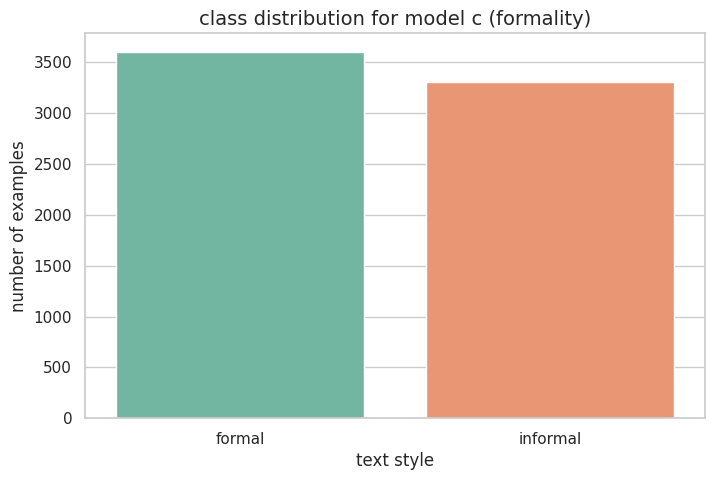

In [13]:
# cell 12: class distribution for model c (formality)
import matplotlib.pyplot as plt
import seaborn as sns

# map numeric labels to string names for the plot
label_map_c = {0: 'informal', 1: 'formal'}
df_formality['style'] = df_formality['label'].map(label_map_c)

# set style and create plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# countplot for classes
sns.countplot(data=df_formality, x='style', palette='Set2')

# add labels and title
plt.title('class distribution for model c (formality)', fontsize=14)
plt.xlabel('text style', fontsize=12)
plt.ylabel('number of examples', fontsize=12)

print("class counts:")
print(df_formality['label'].value_counts())

plt.show()

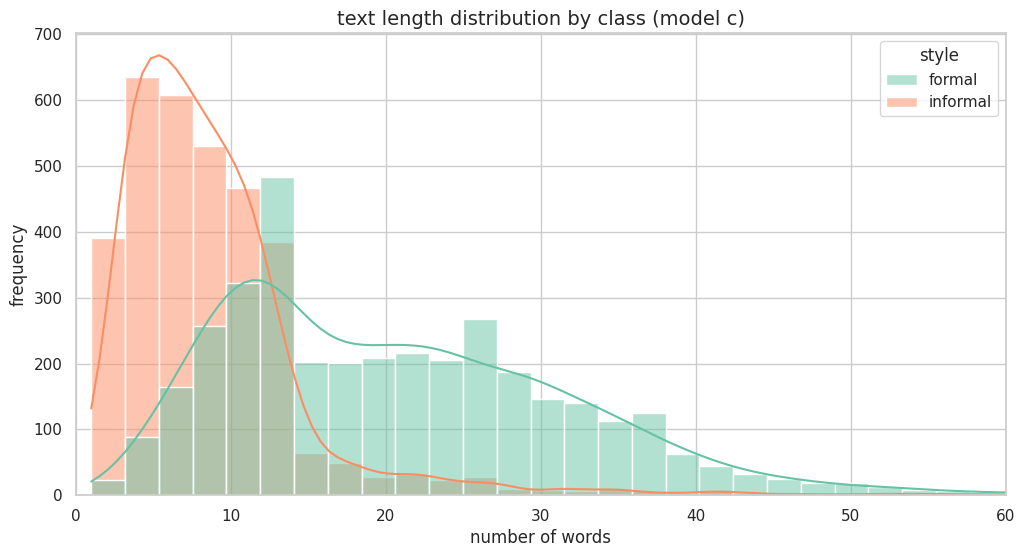

text length statistics by class:
           count       mean        std  min   50%   90%   95%    max
style                                                               
formal    3605.0  20.867961  11.503693  1.0  19.0  36.0  41.0  110.0
informal  3304.0   8.757869   6.254234  1.0   8.0  14.0  19.0   67.0


In [14]:
# cell 13: text length distribution for model c
import matplotlib.pyplot as plt
import seaborn as sns

# calculate word count for each text
df_formality['word_count'] = df_formality['text'].apply(lambda x: len(str(x).split()))

# set style and plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# plot histogram with different colors for each class
sns.histplot(data=df_formality, x='word_count', hue='style', bins=50, kde=True, palette='Set2')

plt.title('text length distribution by class (model c)', fontsize=14)
plt.xlabel('number of words', fontsize=12)
plt.ylabel('frequency', fontsize=12)

# set x-axis limit to cut off extreme outliers for better visualization
plt.xlim(0, 60)

plt.show()

# print statistics to see the exact numbers
print("text length statistics by class:")
print(df_formality.groupby('style')['word_count'].describe(percentiles=[0.5, 0.90, 0.95]))

### eda conclusions for model c (formality)

**1. class balance:**
the dataset is extremely well-balanced (3605 formal vs. 3304 informal examples). no synthetic oversampling or class weights will be required during the modeling phase.

**2. text length distribution:**
there is a natural, expected difference in text length. formal texts are roughly twice as long on average (mean: 21 words) compared to informal texts (mean: 9 words). this is due to the inherent nature of polite, structured language versus concise internet slang. 

**3. next steps:**
this length discrepancy is minor compared to model a. standard tf-idf normalization (l2) and reasonable padding strategies (~40-50 tokens) will be sufficient to handle it without losing semantic context. the dataset is clean, well-bounded, and ready for stage 2 preprocessing.